# Cross-Validation: Validation Curves and CV Curves

This notebook illustrates cross-validation using two examples.

1. A real data example using the `Auto` dataset: we fit polynomial regressions of `mpg` on `horsepower` and compare validation/CV curves.
2. A simulated example: because we know the true data-generating mechanism, we can compare validation and CV curves to the true expected test error curve.

The goal is to understand cross-validation as a method for estimating prediction error and selecting model complexity.

In [24]:
%pip install ISLP

Note: you may need to restart the kernel to use updated packages.


## 0. Imports

We use `scikit-learn` pipelines so that polynomial features are created inside each cross-validation fold. This is the correct workflow.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(123)

## 1. Helper functions

We will fit polynomial regression models of different degrees. The function below creates a scikit-learn pipeline:

\[
X \mapsto (X, X^2, \ldots, X^d) \mapsto \widehat Y.
\]

In [26]:
def make_poly_model(degree):
    """Polynomial regression model of a given degree."""
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )


def cv_mse_curve(X, y, degrees, cv):
    """Compute a cross-validation MSE curve over polynomial degrees."""
    mse_values = []
    for d in degrees:
        model = make_poly_model(d)
        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="neg_mean_squared_error"
        )
        mse_values.append(-scores.mean())
    return np.array(mse_values)

# Part I: Real data example

We first use the `Auto` dataset from ISLP. The goal is to predict miles per gallon (`mpg`) from `horsepower` using polynomial regression.

## 2. Load the Auto data

If the `ISLP` package is not installed, run the following command once in a notebook cell:

```python
%pip install ISLP
```

In [27]:
try:
    from ISLP import load_data
    Auto = load_data("Auto")
except Exception as e:
    raise ImportError(
        "Could not load the Auto dataset. Try running `%pip install ISLP` first."
    ) from e

Auto = Auto.dropna()
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [28]:
X_auto = Auto[["horsepower"]].values
y_auto = Auto["mpg"].values

degrees_auto = np.arange(1, 11)

print(X_auto.shape, y_auto.shape)

(392, 1) (392,)


## 3. Scatterplot: MPG versus horsepower

The relationship is clearly nonlinear. This makes it a natural example for polynomial regression.

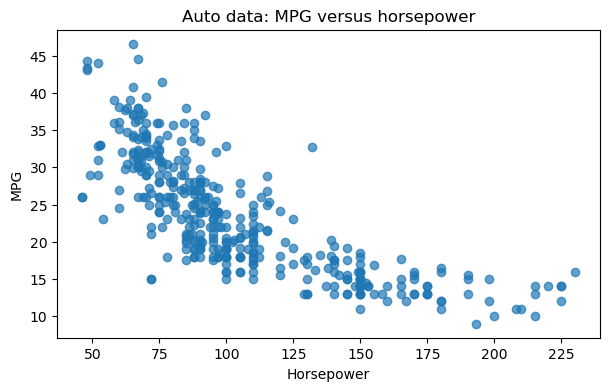

In [29]:
plt.figure(figsize=(7, 4))
plt.scatter(X_auto, y_auto, alpha=0.7)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Auto data: MPG versus horsepower")
plt.show()

## 4. Polynomial fits

We fit polynomial regressions of several degrees. Low degrees may underfit; very high degrees may produce unnecessary wiggles.

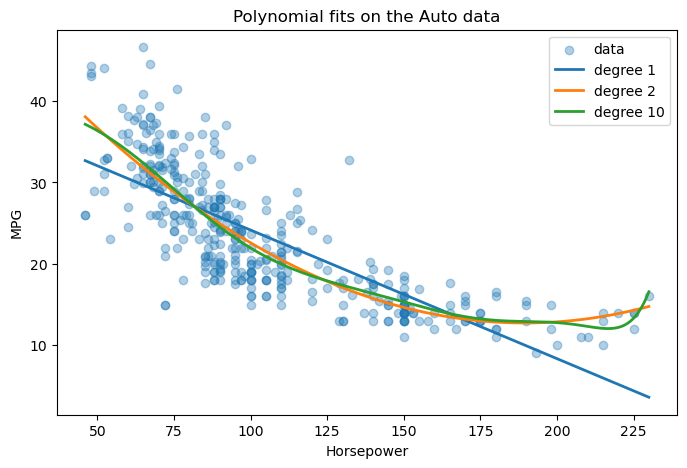

In [30]:
x_grid_auto = np.linspace(X_auto.min(), X_auto.max(), 400).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_auto, y_auto, alpha=0.35, label="data")

for d in [1, 2, 10]:
    model = make_poly_model(d)
    model.fit(X_auto, y_auto)
    y_grid = model.predict(x_grid_auto)
    plt.plot(x_grid_auto, y_grid, linewidth=2, label=f"degree {d}")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial fits on the Auto data")
plt.legend()
plt.show()

## 5. A single validation split

We split the data into two halves. One half is used for training and the other half is used for validation.

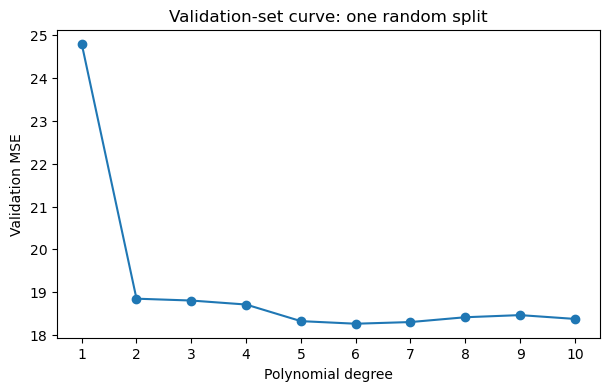

Selected degree: 6


In [31]:
X_train, X_val, y_train, y_val = train_test_split(
    X_auto,
    y_auto,
    test_size=0.5,
    random_state=1
)

val_mse_auto = []

for d in degrees_auto:
    model = make_poly_model(d)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    val_mse_auto.append(mean_squared_error(y_val, pred))

val_mse_auto = np.array(val_mse_auto)

plt.figure(figsize=(7, 4))
plt.plot(degrees_auto, val_mse_auto, marker="o")
plt.xlabel("Polynomial degree")
plt.ylabel("Validation MSE")
plt.title("Validation-set curve: one random split")
plt.xticks(degrees_auto)
plt.show()

print("Selected degree:", degrees_auto[np.argmin(val_mse_auto)])

## 6. Variability of validation splits

The validation-set estimate can depend strongly on the particular random split. We repeat the validation split several times and plot all the validation curves.

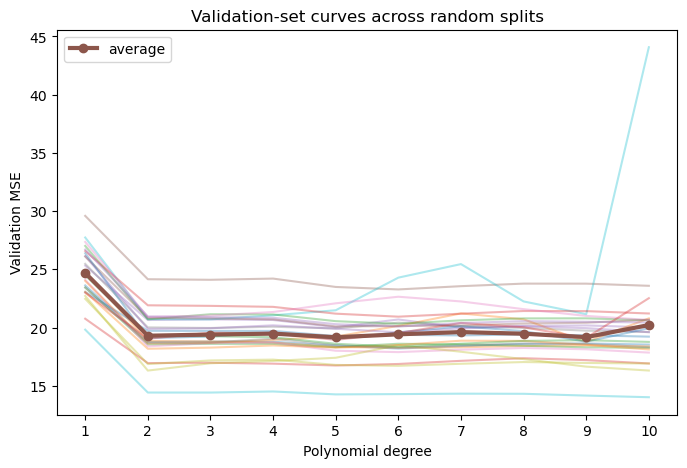

In [32]:
n_splits = 25
all_val_curves = []

for seed in range(n_splits):
    X_train, X_val, y_train, y_val = train_test_split(
        X_auto,
        y_auto,
        test_size=0.5,
        random_state=seed
    )
    curve = []
    for d in degrees_auto:
        model = make_poly_model(d)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        curve.append(mean_squared_error(y_val, pred))
    all_val_curves.append(curve)

all_val_curves = np.array(all_val_curves)

plt.figure(figsize=(8, 5))
for curve in all_val_curves:
    plt.plot(degrees_auto, curve, alpha=0.35)

plt.plot(degrees_auto, all_val_curves.mean(axis=0), marker="o", linewidth=3, label="average")
plt.xlabel("Polynomial degree")
plt.ylabel("Validation MSE")
plt.title("Validation-set curves across random splits")
plt.xticks(degrees_auto)
plt.legend()
plt.show()

## 7. 5-fold, 10-fold, and LOOCV on the Auto data

Now we compare a single validation split with 5-fold CV, 10-fold CV, and leave-one-out cross-validation.

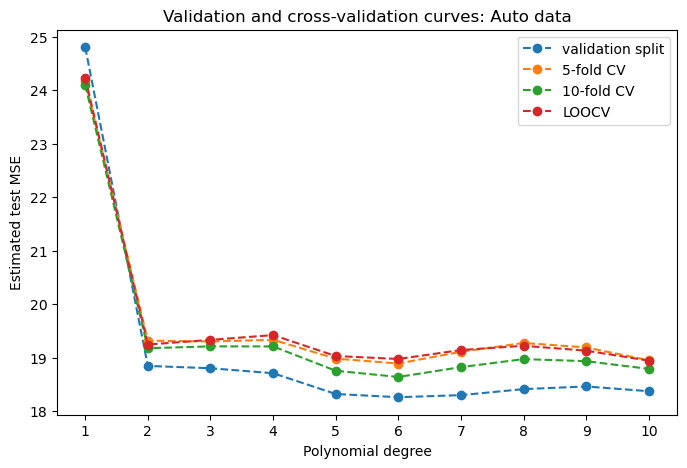

,method,selected_degree,minimum_estimated_MSE
0,validation split,6,18.263611
1,5-fold CV,6,18.893565
2,10-fold CV,6,18.642379
3,LOOCV,10,18.946635


In [33]:
cv5_auto = KFold(n_splits=5, shuffle=True, random_state=1)
cv10_auto = KFold(n_splits=10, shuffle=True, random_state=1)
loo_auto = LeaveOneOut()

mse_5_auto = cv_mse_curve(X_auto, y_auto, degrees_auto, cv5_auto)
mse_10_auto = cv_mse_curve(X_auto, y_auto, degrees_auto, cv10_auto)
mse_loo_auto = cv_mse_curve(X_auto, y_auto, degrees_auto, loo_auto)

plt.figure(figsize=(8, 5))
plt.plot(degrees_auto, val_mse_auto, marker="o", linestyle="--", label="validation split")
plt.plot(degrees_auto, mse_5_auto, marker="o", linestyle="--", label="5-fold CV")
plt.plot(degrees_auto, mse_10_auto, marker="o", linestyle="--", label="10-fold CV")
plt.plot(degrees_auto, mse_loo_auto, marker="o", linestyle="--", label="LOOCV")

plt.xlabel("Polynomial degree")
plt.ylabel("Estimated test MSE")
plt.title("Validation and cross-validation curves: Auto data")
plt.xticks(degrees_auto)
plt.legend()
plt.show()

best_auto = pd.DataFrame({
    "method": ["validation split", "5-fold CV", "10-fold CV", "LOOCV"],
    "selected_degree": [
        degrees_auto[np.argmin(val_mse_auto)],
        degrees_auto[np.argmin(mse_5_auto)],
        degrees_auto[np.argmin(mse_10_auto)],
        degrees_auto[np.argmin(mse_loo_auto)],
    ],
    "minimum_estimated_MSE": [
        val_mse_auto.min(),
        mse_5_auto.min(),
        mse_10_auto.min(),
        mse_loo_auto.min(),
    ]
})

best_auto

The validation split is simple but noisy. Cross-validation uses the data more efficiently by repeatedly training and validating on different subsets.

Next we turn to a simulated example where the true data-generating mechanism is known. This allows us to compare CV curves with the true expected test error curve.

Now we look at the variability of 10 fold cv risk curves. 

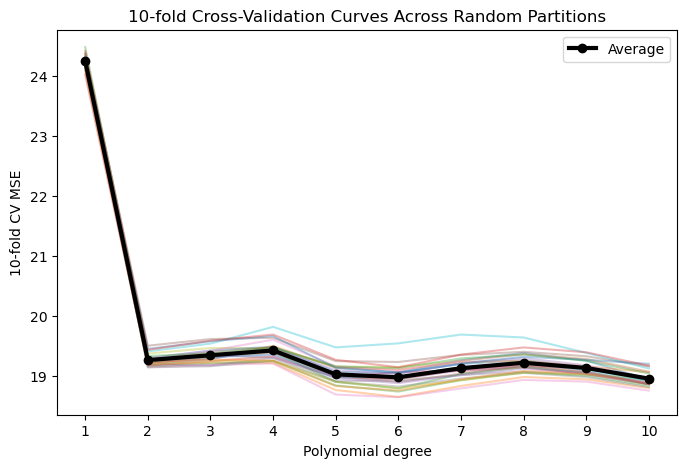

In [34]:
from sklearn.model_selection import KFold, cross_val_score

n_reps = 25
all_cv10_curves = []

for seed in range(n_reps):

    cv = KFold(
        n_splits=10,
        shuffle=True,
        random_state=seed
    )

    curve = []

    for d in degrees_auto:

        model = make_poly_model(d)

        mse = -cross_val_score(
            model,
            X_auto,
            y_auto,
            cv=cv,
            scoring="neg_mean_squared_error"
        ).mean()

        curve.append(mse)

    all_cv10_curves.append(curve)

all_cv10_curves = np.array(all_cv10_curves)

plt.figure(figsize=(8,5))

for curve in all_cv10_curves:
    plt.plot(degrees_auto, curve, alpha=0.35)

plt.plot(
    degrees_auto,
    all_cv10_curves.mean(axis=0),
    color="black",
    linewidth=3,
    marker="o",
    label="Average"
)

plt.xlabel("Polynomial degree")
plt.ylabel("10-fold CV MSE")
plt.title("10-fold Cross-Validation Curves Across Random Partitions")
plt.xticks(degrees_auto)
plt.legend()

plt.show()

We plot the standard errors of the estimated risk for both the pure validation set approach and 10 fold CV. 


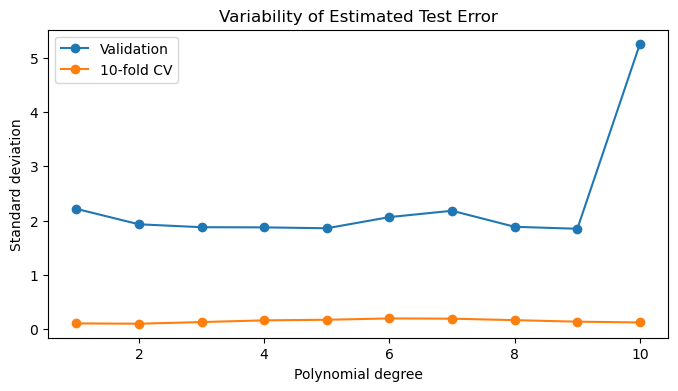

In [35]:
validation_sd = all_val_curves.std(axis=0)
cv10_sd = all_cv10_curves.std(axis=0)

plt.figure(figsize=(8,4))

plt.plot(degrees_auto, validation_sd,
         marker='o', label='Validation')

plt.plot(degrees_auto, cv10_sd,
         marker='o', label='10-fold CV')

plt.xlabel("Polynomial degree")
plt.ylabel("Standard deviation")
plt.title("Variability of Estimated Test Error")

plt.legend()

plt.show()

# Part II: Simulated data example

We simulate data from the nonlinear regression model

$$
Y = f(X) + \varepsilon,
$$

where

$$
f(x) = \sin(2\pi x) + 0.5\sin(8\pi x),
$$

and

$$
X \sim \mathrm{Uniform}(0,1),
\qquad
\varepsilon \sim N(0,0.3^2).
$$

Since the data-generating mechanism is known, we can approximate the **true
expected test error** for each polynomial degree by repeatedly generating
training datasets and evaluating the fitted models on large independent test
sets.

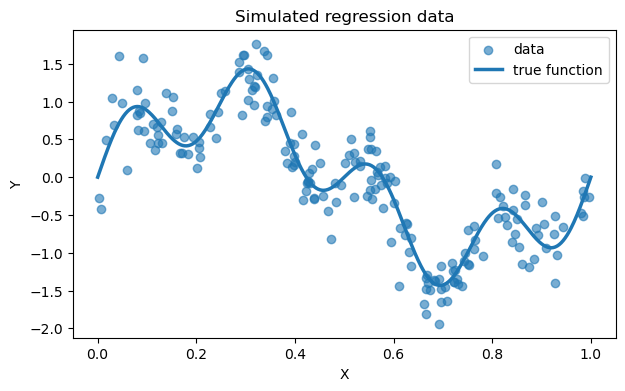

In [36]:
np.random.seed(123)

def f_true(x):
    return np.sin(2 * np.pi * x) + 0.5 * np.sin(8 * np.pi * x)

sigma = 0.3
n = 200
degrees = np.arange(1, 21)

X = np.random.uniform(0, 1, size=n)
y = f_true(X) + sigma * np.random.randn(n)
X = X.reshape(-1, 1)

x_grid = np.linspace(0, 1, 500).reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, alpha=0.6, label="data")
plt.plot(x_grid, f_true(x_grid.ravel()), linewidth=2.5, label="true function")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Simulated regression data")
plt.legend()
plt.show()

## 8. Polynomial fits on the simulated data

We fit polynomial regressions of different degrees to the same simulated dataset.

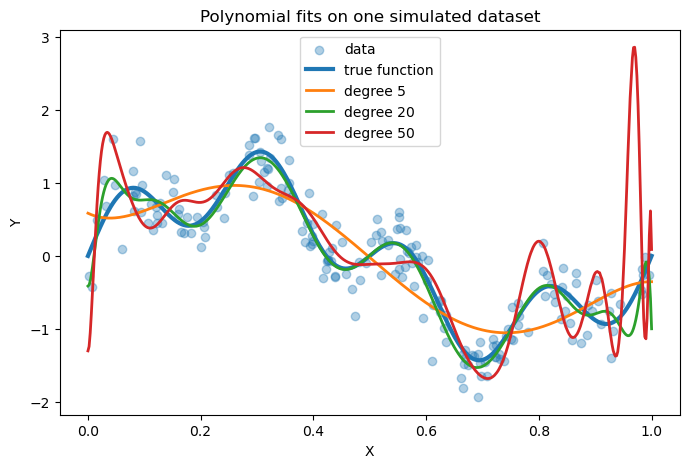

In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.35, label="data")
plt.plot(x_grid, f_true(x_grid.ravel()), linewidth=3, label="true function")

for d in [5, 20,50]:
    model = make_poly_model(d)
    model.fit(X, y)
    y_grid = model.predict(x_grid)
    plt.plot(x_grid, y_grid, linewidth=2, label=f"degree {d}")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial fits on one simulated dataset")
plt.legend()
plt.show()

## 9. Approximate the true expected test error curve

For each polynomial degree \(d\), we approximate

$$
R(d)
=
\mathbb{E}_{D_n}
\!\left[
\mathbb{E}
\!\left(
(Y-\widehat{f}_d(X))^2
\,\middle|\,
D_n
\right)
\right].
$$

This is done by repeatedly generating independent training datasets,
fitting a polynomial of degree \(d\), and evaluating the fitted model
on a large independent test set.

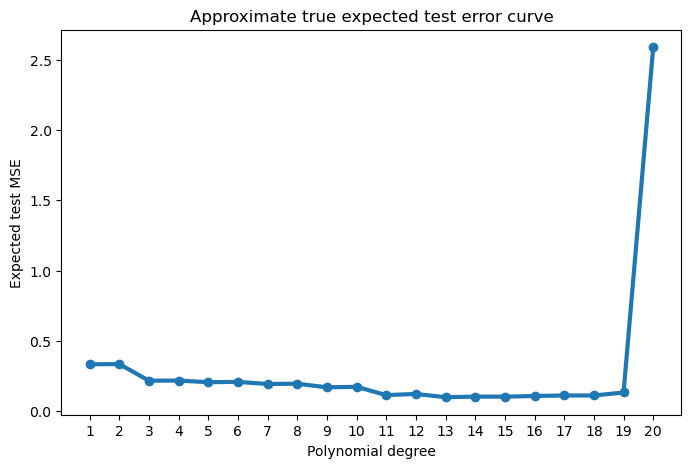

Best degree according to approximate true expected test error: 13


In [38]:
# This cell may take a little time.

n_train_reps = 300
n_test = 5000

true_risk = []

for d in degrees:
    risks_d = []
    
    for r in range(n_train_reps):
        X_train_sim = np.random.uniform(0, 1, size=n).reshape(-1, 1)
        y_train_sim = f_true(X_train_sim.ravel()) + sigma * np.random.randn(n)

        X_test_sim = np.random.uniform(0, 1, size=n_test).reshape(-1, 1)
        y_test_sim = f_true(X_test_sim.ravel()) + sigma * np.random.randn(n_test)

        model = make_poly_model(d)
        model.fit(X_train_sim, y_train_sim)
        pred = model.predict(X_test_sim)
        risks_d.append(mean_squared_error(y_test_sim, pred))
    
    true_risk.append(np.mean(risks_d))

true_risk = np.array(true_risk)

plt.figure(figsize=(8, 5))
plt.plot(degrees, true_risk, marker="o", linewidth=3)
plt.xlabel("Polynomial degree")
plt.ylabel("Expected test MSE")
plt.title("Approximate true expected test error curve")
plt.xticks(degrees)
plt.show()

print("Best degree according to approximate true expected test error:", degrees[np.argmin(true_risk)])

## 10. One realization of validation and CV curves

Now pretend that the simulated dataset above is the only data we have. We compute one validation curve, one 5-fold CV curve, one 10-fold CV curve, and one LOOCV curve.

In [39]:
# One validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=1
)

validation_mse = []

for d in degrees:
    model = make_poly_model(d)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    validation_mse.append(mean_squared_error(y_val, pred))

validation_mse = np.array(validation_mse)

# Cross-validation curves
cv5 = KFold(n_splits=5, shuffle=True, random_state=1)
cv10 = KFold(n_splits=10, shuffle=True, random_state=1)
loo = LeaveOneOut()

cv5_mse = cv_mse_curve(X, y, degrees, cv5)
cv10_mse = cv_mse_curve(X, y, degrees, cv10)
loo_mse = cv_mse_curve(X, y, degrees, loo)

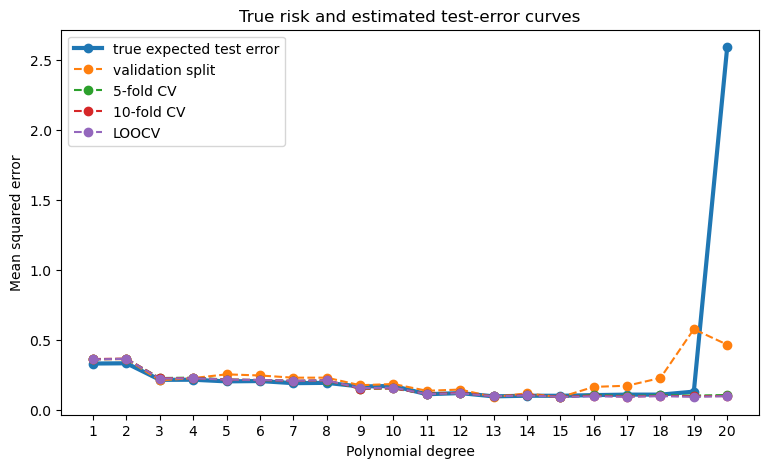

In [40]:
plt.figure(figsize=(9, 5))

plt.plot(degrees, true_risk, marker="o", linewidth=3, label="true expected test error")
plt.plot(degrees, validation_mse, marker="o", linestyle="--", label="validation split")
plt.plot(degrees, cv5_mse, marker="o", linestyle="--", label="5-fold CV")
plt.plot(degrees, cv10_mse, marker="o", linestyle="--", label="10-fold CV")
plt.plot(degrees, loo_mse, marker="o", linestyle="--", label="LOOCV")

plt.xlabel("Polynomial degree")
plt.ylabel("Mean squared error")
plt.title("True risk and estimated test-error curves")
plt.xticks(degrees)
plt.legend()
plt.show()

In [41]:
best_degrees = pd.DataFrame({
    "method": [
        "true expected test error",
        "validation split",
        "5-fold CV",
        "10-fold CV",
        "LOOCV"
    ],
    "selected_degree": [
        degrees[np.argmin(true_risk)],
        degrees[np.argmin(validation_mse)],
        degrees[np.argmin(cv5_mse)],
        degrees[np.argmin(cv10_mse)],
        degrees[np.argmin(loo_mse)]
    ],
    "minimum_MSE": [
        true_risk.min(),
        validation_mse.min(),
        cv5_mse.min(),
        cv10_mse.min(),
        loo_mse.min()
    ]
})

best_degrees

,method,selected_degree,minimum_MSE
0,true expected test error,13,0.099163
1,validation split,15,0.092963
2,5-fold CV,15,0.093756
3,10-fold CV,15,0.095231
4,LOOCV,15,0.094751
